In [22]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
concrete_ds=pd.read_csv("data/concrete_data.csv")
concrete_ds.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [23]:
concrete_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [24]:
concrete_ds.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [25]:
print(concrete_ds.isna().sum().sum())
print(concrete_ds.duplicated().sum())

0
25


In [26]:
concrete_ds.drop_duplicates(inplace=True)
concrete_ds.duplicated().sum()

np.int64(0)

In [27]:
concrete_ds.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


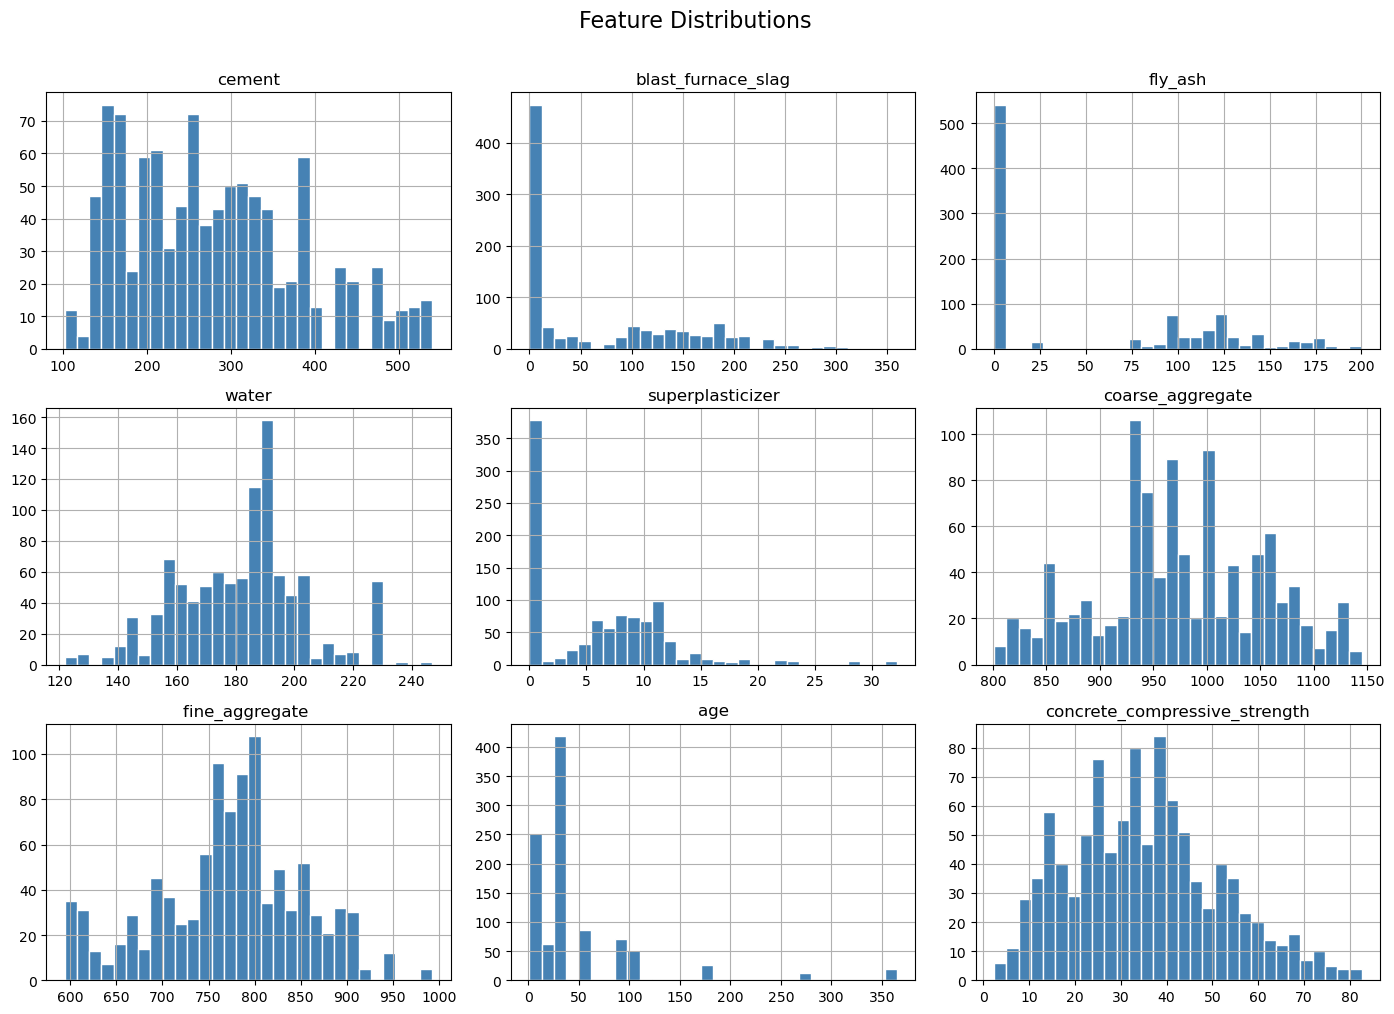

In [28]:
target = "concrete_compressive_strength"
features = [c for c in concrete_ds.columns if c != target]

# ── 1. Histograms — distribution of every variable ─────────
concrete_ds.hist(figsize=(14, 10), bins=30, color="steelblue", edgecolor="white")
plt.suptitle("Feature Distributions", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

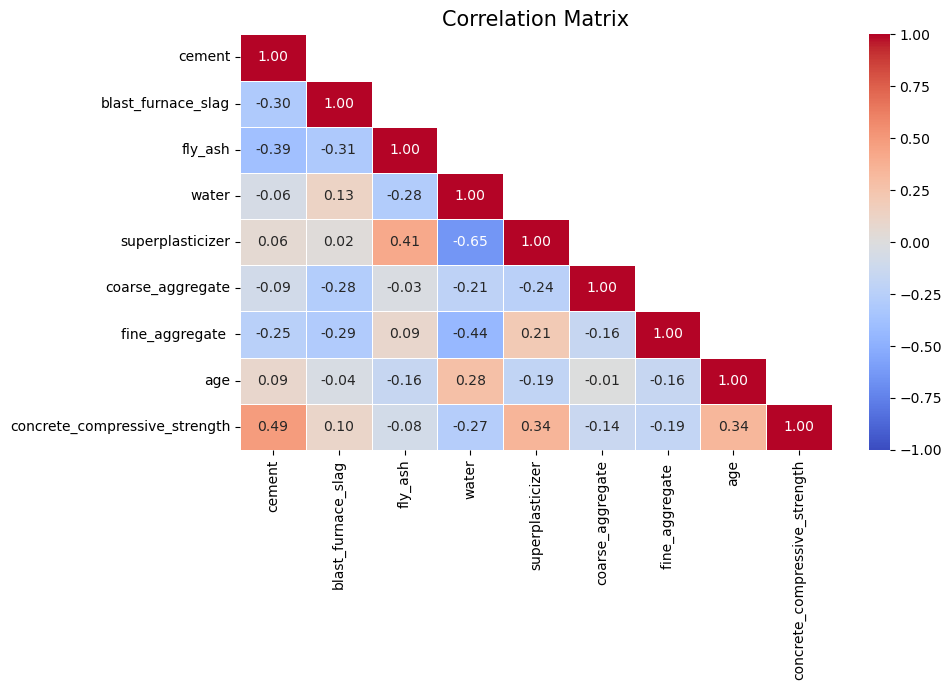

In [29]:
plt.figure(figsize=(10, 7))
corr = concrete_ds.corr()
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
# mask upper triangle
import numpy as np
mask_upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask_upper, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix", fontsize=15)
plt.tight_layout()
plt.show()

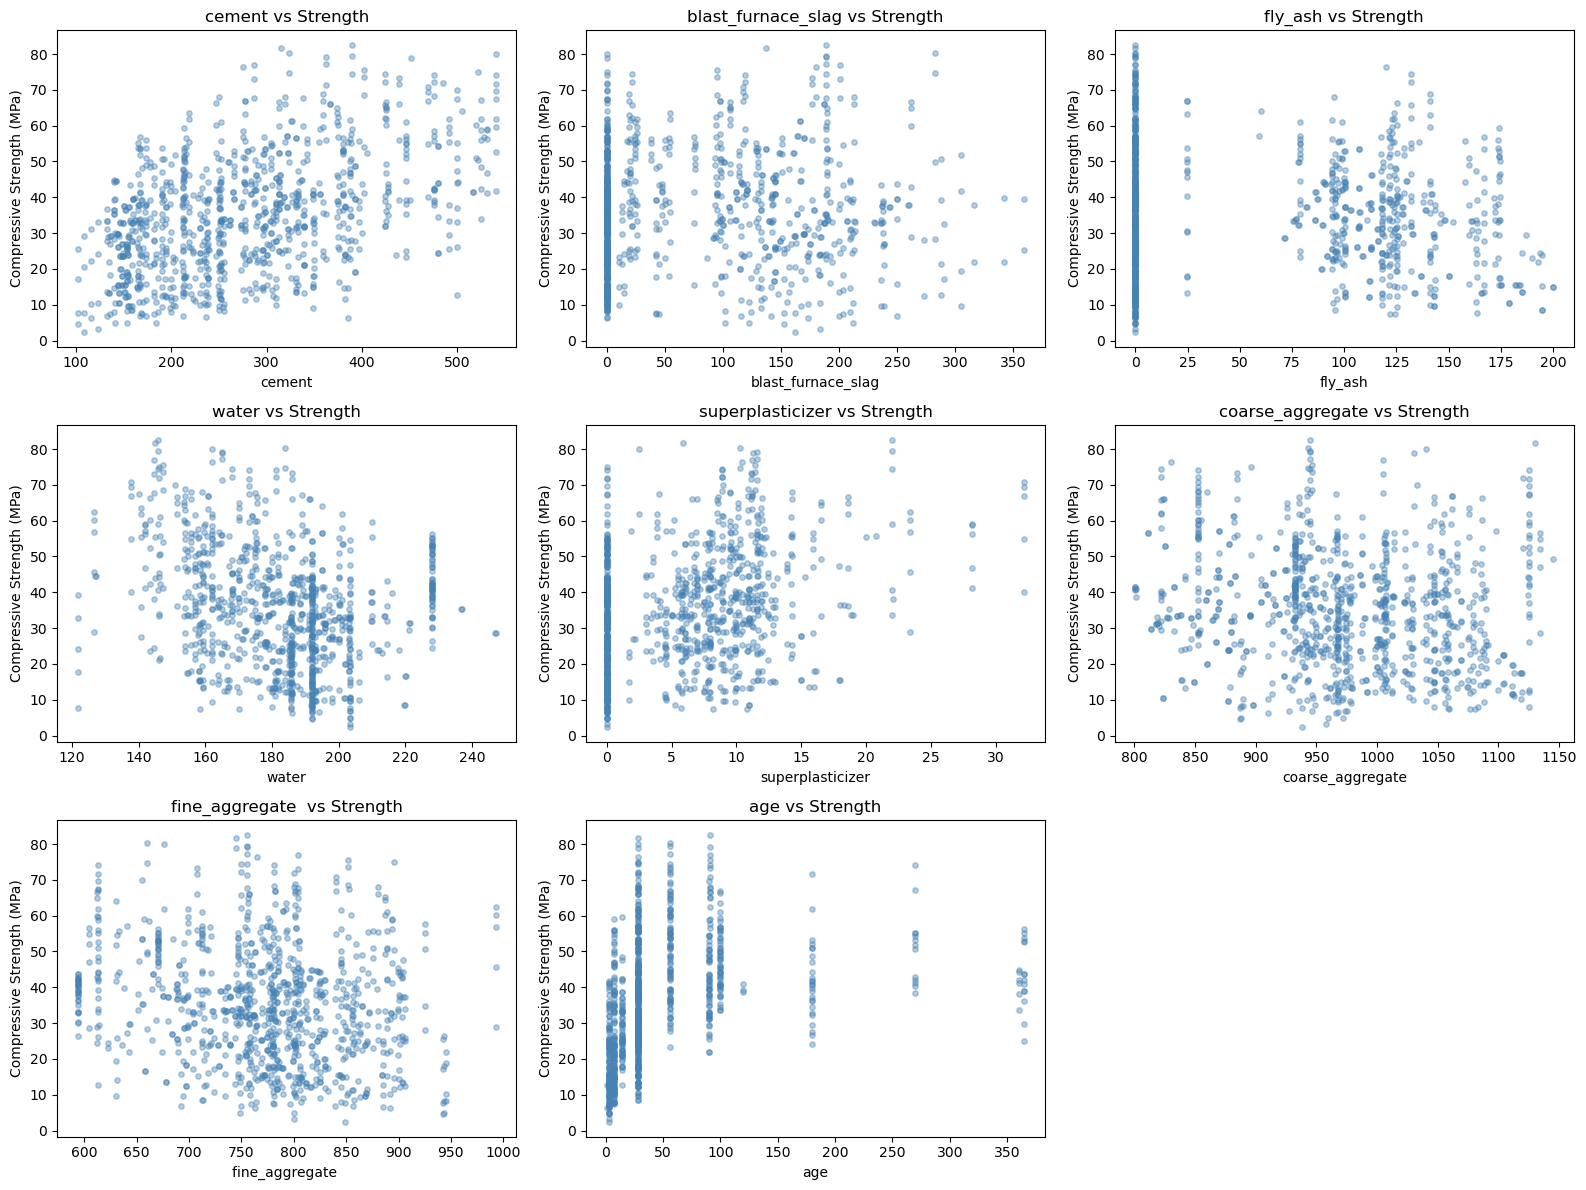

In [30]:
n = len(features)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].scatter(concrete_ds[feat], concrete_ds[target], alpha=0.4, color="steelblue", s=15)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Compressive Strength (MPa)")
    axes[i].set_title(f"{feat} vs Strength")

for j in range(i + 1, len(axes)):      # hide empty subplots
    axes[j].set_visible(False)
    
plt.tight_layout()
plt.show()


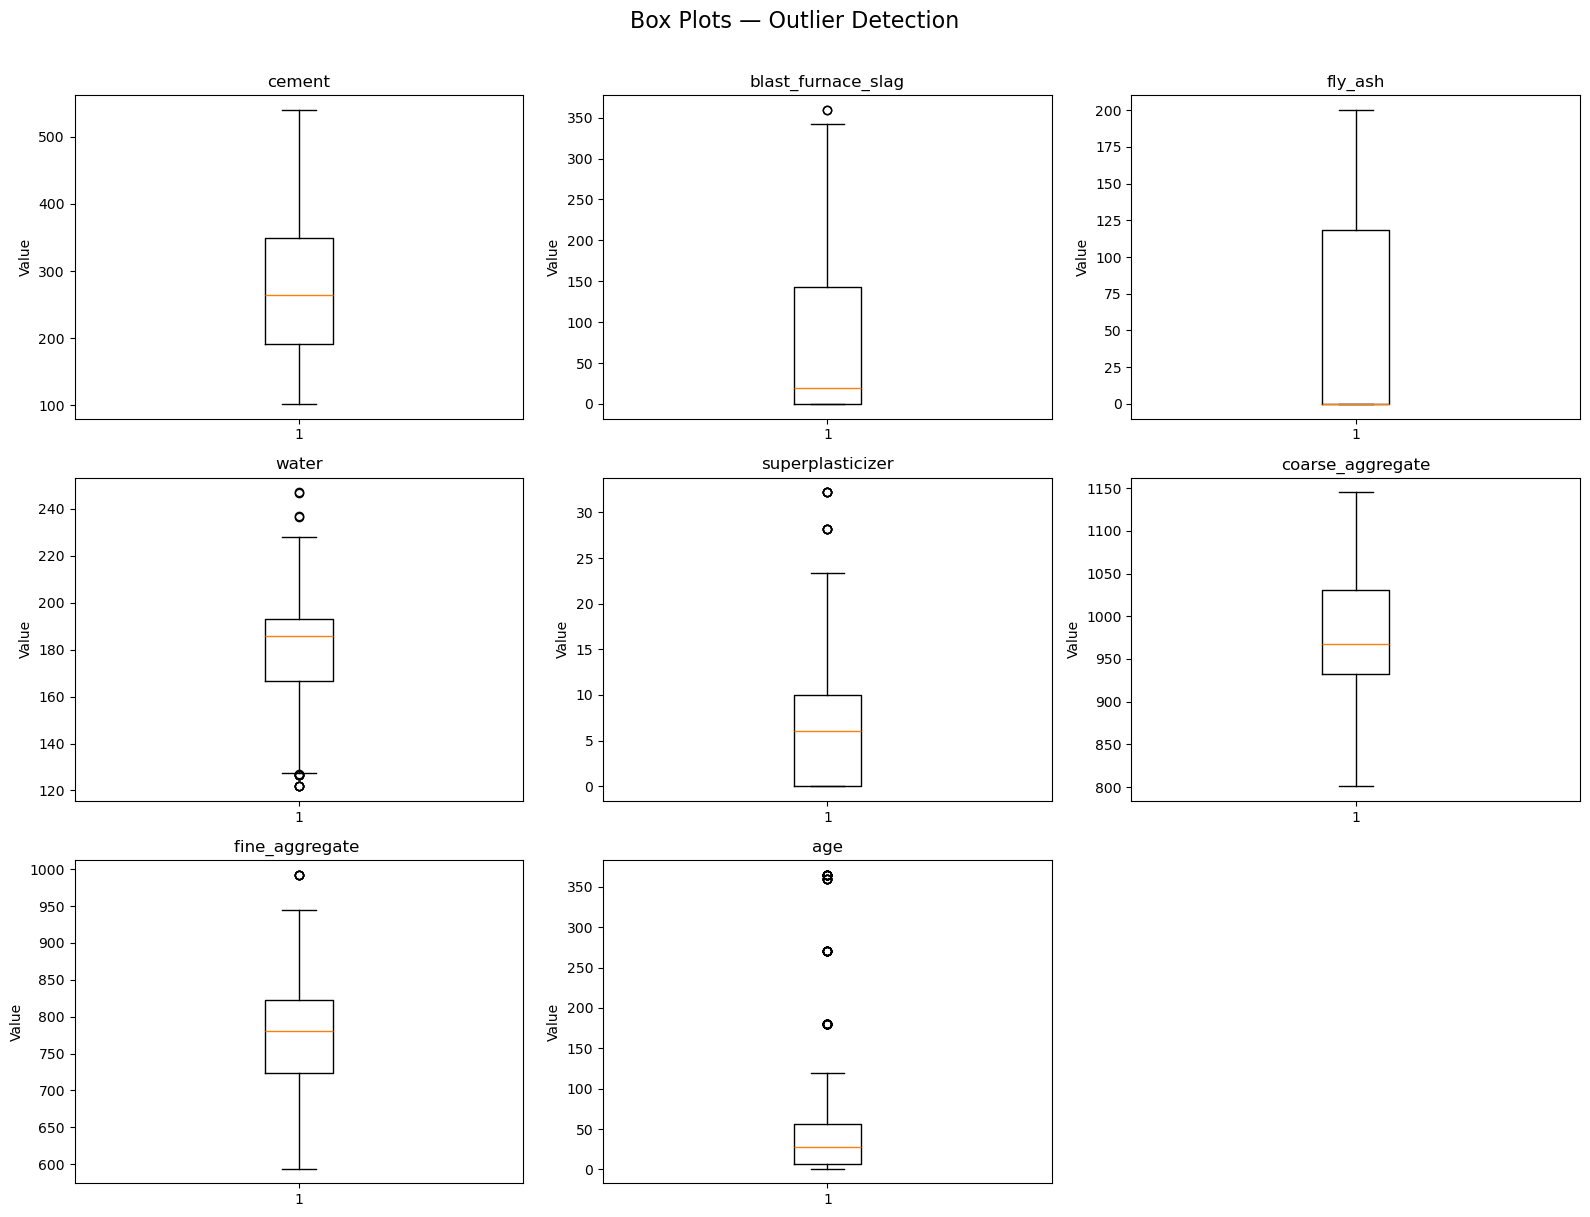

In [31]:
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].boxplot(concrete_ds[feat])
    axes[i].set_title(feat)
    axes[i].set_ylabel("Value")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Box Plots — Outlier Detection", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

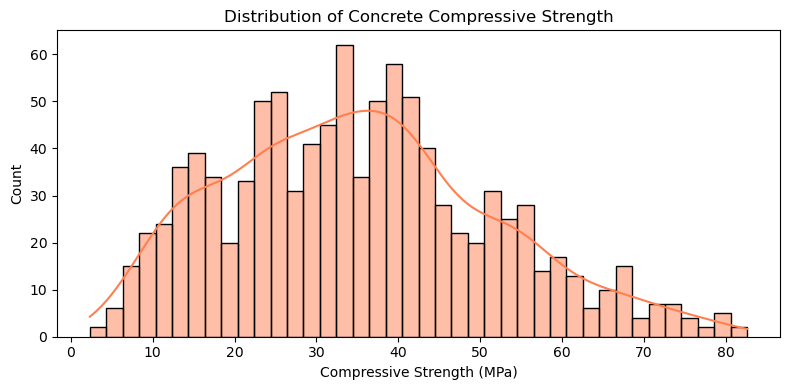

In [32]:
plt.figure(figsize=(8, 4))
sns.histplot(concrete_ds[target], kde=True, color="coral", bins=40)
plt.title("Distribution of Concrete Compressive Strength")
plt.xlabel("Compressive Strength (MPa)")
plt.tight_layout()
plt.show()

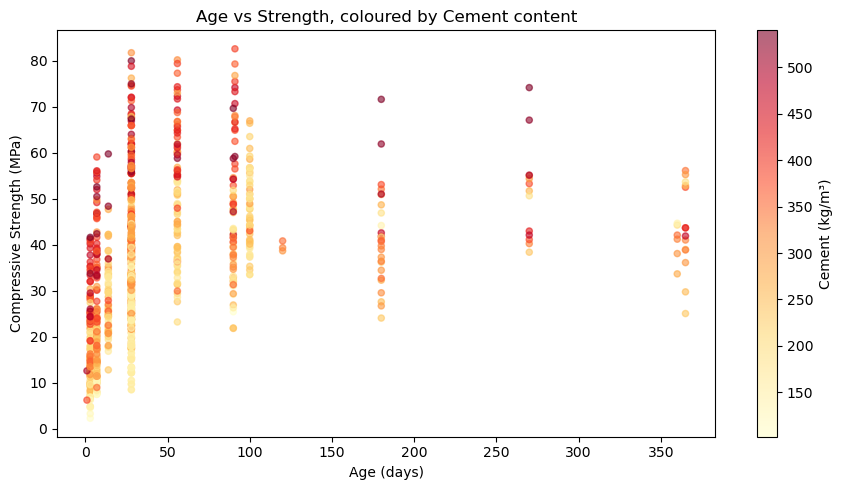

In [33]:
plt.figure(figsize=(9, 5))
sc = plt.scatter(concrete_ds["age"], concrete_ds[target],
                 c=concrete_ds["cement"], cmap="YlOrRd", alpha=0.6, s=20)
plt.colorbar(sc, label="Cement (kg/m³)")
plt.xlabel("Age (days)")
plt.ylabel("Compressive Strength (MPa)")
plt.title("Age vs Strength, coloured by Cement content")
plt.tight_layout()
plt.show()

In [34]:
target = "concrete_compressive_strength"
X = concrete_ds.drop(columns=[target])
y = concrete_ds[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")


Train size: (804, 8), Test size: (201, 8)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:30s} | RMSE: {rmse:.2f} | MAE: {mae:.2f} | R²: {r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

models = {
    "Linear Regression":        LinearRegression(),
    "Random Forest":            RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":        GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = []
trained = {}

print(f"{'Model':30s} | {'RMSE':>8} | {'MAE':>7} | {'R²':>7}")
print("-" * 60)

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    results.append(evaluate(name, y_test, preds))
    trained[name] = (model, preds)

Model                          |     RMSE |     MAE |      R²
------------------------------------------------------------
Linear Regression              | RMSE: 11.19 | MAE: 8.90 | R²: 0.5802
Random Forest                  | RMSE: 5.26 | MAE: 3.50 | R²: 0.9074
Gradient Boosting              | RMSE: 4.92 | MAE: 3.56 | R²: 0.9189


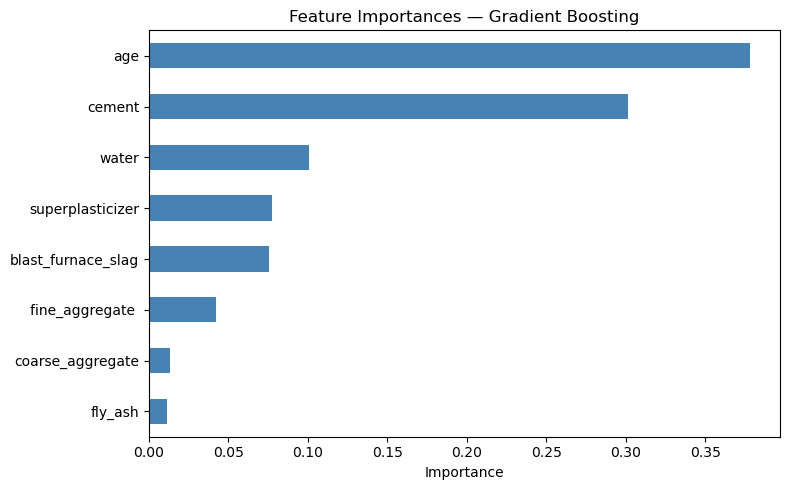

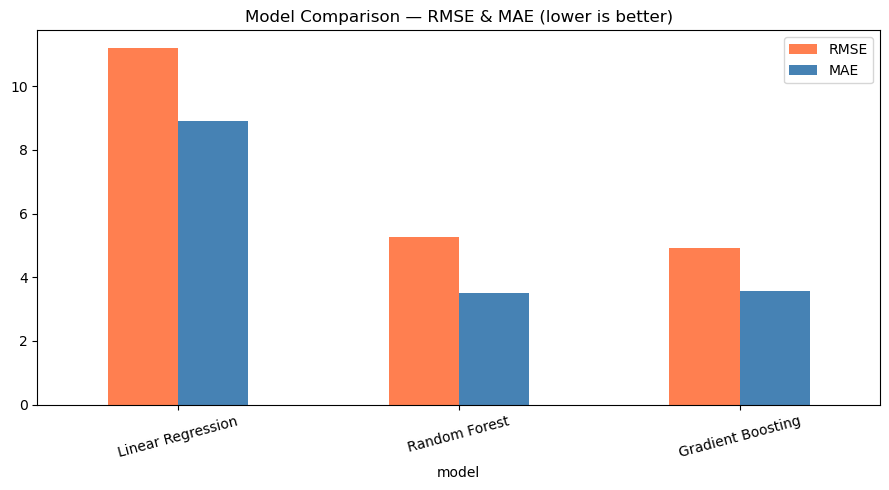

In [ ]:
import matplotlib.pyplot as plt

# ── Feature Importance (Gradient Boosting) ────────────────────
gb_model = trained["Gradient Boosting"][0]
importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importances — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ── Model comparison bar chart ─────────────────────────────
results_df = pd.DataFrame(results).set_index("model")

results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(9, 5), color=["coral", "steelblue"])
plt.title("Model Comparison — RMSE & MAE (lower is better)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()